In [1]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import xarray as xr
import numpy as np
import pandas as pd
from scipy.special import expit 
import os
import cftime

In [2]:
filedir = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/avg_climate'
filedir2 = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/hist'

In [3]:
hist_temp = xr.open_dataset(filedir2 + '/b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.TS.19780101-20141231.nc')
hist_precip = xr.open_dataset(filedir2 + '/b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.PRECT.19780101-20141231.nc')
hist_fsds = xr.open_dataset(filedir2 + '/b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.cam.h1.FSDS.19780101-20141231.nc')
hist_vpd = xr.open_dataset(filedir2 + '/b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1978_2014.001.cam.h1.VPD.19780101-20141231.nc')
hist_smp = xr.open_dataset(filedir2 + '/b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_2014.001.clm2.h3.SMP.latlonsam.19780101-20141231.nc')

In [4]:
hist_temp = hist_temp.TS
hist_temp = hist_temp.sel(time=slice('1990-01-01', '2009-12-31'))
hist_temp = hist_temp.mean(dim='time')

In [5]:
hist_precip = hist_precip.PRECT
hist_precip = hist_precip.sel(time=slice('1990-01-01', '2009-12-31'))
hist_precip = hist_precip.mean(dim='time')

In [6]:
hist_fsds = hist_fsds.FSDS
hist_fsds = hist_fsds.sel(time=slice('1990-01-01', '2009-12-31'))
hist_fsds = hist_fsds.mean(dim='time')

In [7]:
hist_vpd = hist_vpd.VPD
hist_vpd = hist_vpd.sel(time=slice('1990-01-01', '2009-12-31'))
hist_vpd = hist_vpd.mean(dim='time')

In [8]:
idx = hist_smp.get_index("time")         
dupes = idx[idx.duplicated()]     
print(f"{dupes.size} duplicate dates found")

21 duplicate dates found


In [9]:
idx = hist_smp.indexes["time"]                 
unique_sel = ~idx.duplicated()                   
hist_smp = hist_smp.isel(time=unique_sel)          
assert hist_smp.indexes["time"].is_unique
assert hist_smp.time.size == 13505

In [10]:
hist_smp = hist_smp.SMP_GRIDCELL
hist_smp = hist_smp.sel(time=slice('1990-01-01', '2009-12-31'))
hist_smp = hist_smp.mean(dim='time')

In [11]:
fut_temp = xr.open_dataset(filedir + '/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.AVG.cam.h1.TS.20150101-20691231.nc')
fut_precip = xr.open_dataset(filedir + '/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.AVG.cam.h1.PRECT.20150101-20691231.nc')
fut_fsds = xr.open_dataset(filedir + '/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.AVG.cam.h1.FSDS.20150101-20691231.nc')
fut_vpd = xr.open_dataset(filedir + '/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.AVG.cam.h1.VPD.20150101-20691231.nc')
fut_smp = xr.open_dataset(filedir + '/b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.AVG.clm2.h3.SMP.latlonsam.20150101-20691231.nc')

In [12]:
fut_temp = fut_temp.TS
fut_temp = fut_temp.sel(time=slice('2050-01-01', '2069-12-30'))
fut_temp = fut_temp.mean(dim='time')

In [13]:
fut_precip = fut_precip.PRECT
fut_precip = fut_precip.sel(time=slice('2050-01-01', '2069-12-30'))
fut_precip = fut_precip.mean(dim='time')

In [14]:
fut_fsds = fut_fsds.FSDS
fut_fsds = fut_fsds.sel(time=slice('2050-01-01', '2069-12-30'))
fut_fsds = fut_fsds.mean(dim='time')

In [15]:
fut_vpd = fut_vpd.VPD
fut_vpd = fut_vpd.sel(time=slice('2050-01-01', '2069-12-30'))
fut_vpd = fut_vpd.mean(dim='time')

In [16]:
idx = fut_smp.get_index("time")         
dupes = idx[idx.duplicated()]     
print(f"{dupes.size} duplicate dates found")

30 duplicate dates found


In [17]:
idx = fut_smp.indexes["time"]                 
unique_sel = ~idx.duplicated()                   
fut_smp = fut_smp.isel(time=unique_sel)          
assert fut_smp.indexes["time"].is_unique
assert fut_smp.time.size == 20075

In [18]:
fut_smp = fut_smp.SMP_GRIDCELL
fut_smp = fut_smp.sel(time=slice('2050-01-01', '2069-12-30'))
fut_smp = fut_smp.mean(dim='time')

In [19]:
dif_temp = (fut_temp - hist_temp)
dif_precip = (fut_precip - hist_precip) / hist_precip
dif_precip = dif_precip * 100
dif_fsds = (fut_fsds - hist_fsds)
dif_vpd = (fut_vpd - hist_vpd) / hist_vpd
dif_vpd = dif_vpd * 100
dif_smp = (fut_smp - hist_smp) 
#dif_smp = dif_smp * 100

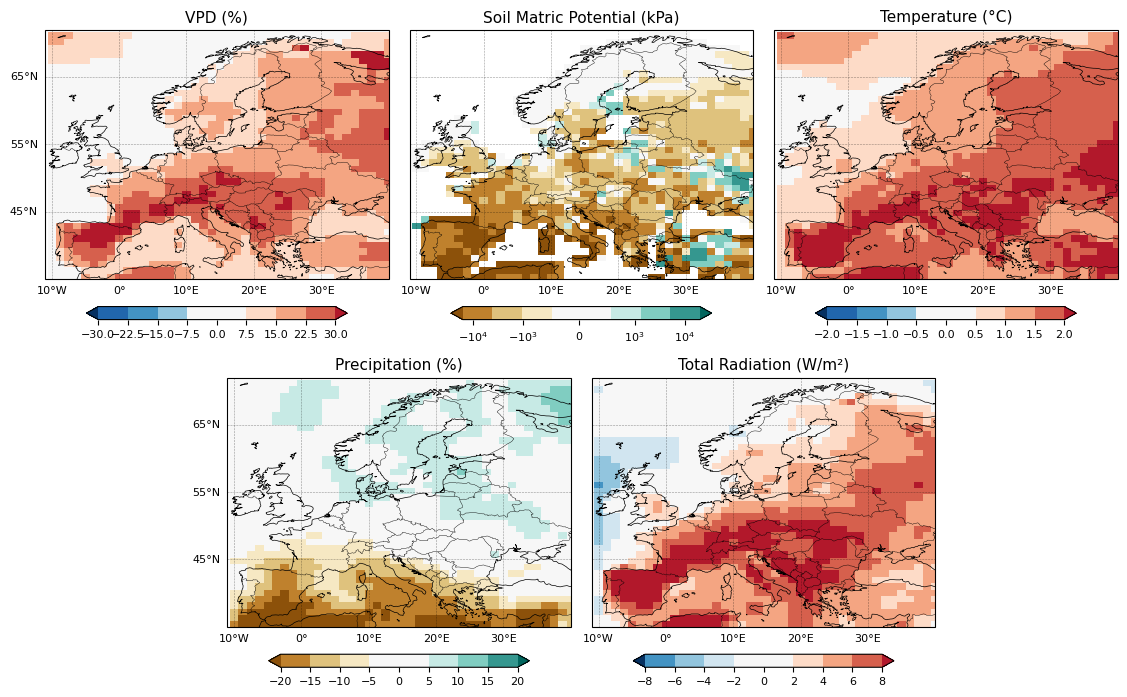

In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from matplotlib.colors import SymLogNorm
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Define color levels 
dif_levels_1 = np.arange(-2, 2.5, 0.5)
dif_colors_1 = ['#053061','#2166ac','#4393c3','#92c5de','#f7f7f7','#f7f7f7',
                '#fddbc7','#f4a582','#d6604d','#b2182b']

dif_levels_2 = np.arange(-20, 25, 5)
dif_colors_2 = ['#8c510a','#bf812d','#dfc27d','#f6e8c3','#f7f7f7',
                '#f7f7f7','#c7eae5','#80cdc1','#35978f','#01665e']

dif_levels_3 = np.arange(-8, 10, 2)
dif_colors_3 = ['#053061','#4393c3','#92c5de','#d1e5f0','#f7f7f7',
                '#f7f7f7','#fddbc7','#f4a582','#d6604d','#b2182b']

dif_levels_4 = np.arange(-30, 37.5, 7.5)
dif_colors_4 = ['#053061','#2166ac','#4393c3','#92c5de','#f7f7f7','#f7f7f7',
                '#fddbc7','#f4a582','#d6604d','#b2182b']

dif_levels_5 = np.arange(-16000, 20000, 4000)
dif_colors_5 = ['#8c510a','#bf812d','#dfc27d','#f6e8c3','#f7f7f7',
                '#f7f7f7','#c7eae5','#80cdc1','#35978f','#01665e']

maps = [
    (dif_vpd,    "VPD (%)", dif_levels_4, dif_colors_4, False),
    (dif_smp,    "Soil Matric Potential (kPa)", dif_levels_5, dif_colors_5, True),
    (dif_temp,   "Temperature (°C)", dif_levels_1, dif_colors_1, False),
    (dif_precip, "Precipitation (%)", dif_levels_2, dif_colors_2, False),
    (dif_fsds,   "Total Radiation (W/m²)", dif_levels_3, dif_colors_3, False),
]

fig = plt.figure(figsize=(11.5, 7))
gs = fig.add_gridspec(nrows=2, ncols=6)

axes = [
    fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree()),  # top-left
    fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree()),  # top-middle
    fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree()),  # top-right
    fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree()),  # bottom-left (centered)
    fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())   # bottom-right (centered)
]

for i, (da, title, clevels, ccolors, use_symlog) in enumerate(maps):
    ax = axes[i]

    # Fix longitude range and subset to Europe
    if da.lon.max() > 180:
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby('lon')
    da = da.sel(lat=slice(35, 72), lon=slice(-11, 40))
    da = da.where(np.isfinite(da), drop=True)

    # Log scale for SMP only
    norm = SymLogNorm(linthresh=1000, linscale=1, vmin=-16000, vmax=20000) if use_symlog else None

    # Map plot
    pcm = da.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(),
        levels=clevels, colors=ccolors, norm=norm,
        add_colorbar=False, extend='both'
    )
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_xlim(-11, 40)
    ax.set_ylim(35, 72)
    ax.set_title(title, fontsize=11)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=0.4, color="black", alpha=0.4, linestyle="--",
        draw_labels=True
    )
    gl.ylocator = mticker.FixedLocator([35, 45, 55, 65, 75])
    gl.xlocator = mticker.FixedLocator([-10, 0, 10, 20, 30, 40])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    gl.top_labels = False
    gl.right_labels = False

    if i not in [0, 3]:
        gl.left_labels = False

    # Keep bottom labels on all subplots
    gl.bottom_labels = True

    # Colorbar
    cbar = plt.colorbar(
        pcm, ax=ax, orientation="horizontal",
        fraction=0.045, pad=0.095, extend='both'
    )
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.20)

plt.savefig(
    filedir + "/Europe_climate_differences_SSP245minusHist.png",
    dpi=600, bbox_inches="tight", pad_inches=0.05
)
# plt.show()